In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("data/loan_default.csv")
print(f"Shape: {df.shape}")
print(df.dtypes)
print(df.info())
print(df.describe())
print(df.head())

Shape: (2000, 16)
age                     int64
gender                 object
education              object
marital_status         object
num_dependents          int64
annual_income         float64
credit_score          float64
existing_debt           int64
num_credit_cards      float64
months_employed       float64
loan_amount             int64
loan_term_months        int64
loan_purpose           object
interest_rate         float64
property_ownership     object
loan_default            int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 2000 non-null   int64  
 1   gender              2000 non-null   object 
 2   education           2000 non-null   object 
 3   marital_status      2000 non-null   object 
 4   num_dependents      2000 non-null   int64  
 5   annual_income       1917 non-null

In [3]:
counts = df['loan_default'].value_counts()
pct = df['loan_default'].value_counts(normalize=True) * 100
missing = df.isnull().sum()
pct_miss = (missing / len(df) * 100).round(2)

print(f"Tra dung han (0): {counts[0]} - {pct[0]}%")
print(f"Vo no (1): {counts[1]} - {pct[1]}%")
reports = pd.DataFrame({"Counts" : missing, "Percent" : pct_miss})
print(reports[reports['Counts'] > 0])

Tra dung han (0): 1238 - 61.9%
Vo no (1): 762 - 38.1%
                  Counts  Percent
annual_income         83     4.15
credit_score         118     5.90
num_credit_cards      48     2.40
months_employed       74     3.70


In [4]:
numeric_cols = df.select_dtypes(['float64'], ['int64']).columns

for col in numeric_cols:
    if df[col].nunique() > 10:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        
        if outliers > 0:
            print(f"Col: {col} - {outliers} outliers - range [{lower:.1f}, {upper:.1f}]")

Col: annual_income - 25 outliers - range [-7100.0, 113700.0]
Col: credit_score - 9 outliers - range [436.0, 860.0]
Col: months_employed - 97 outliers - range [-65.5, 146.5]
Col: interest_rate - 13 outliers - range [0.4, 16.5]


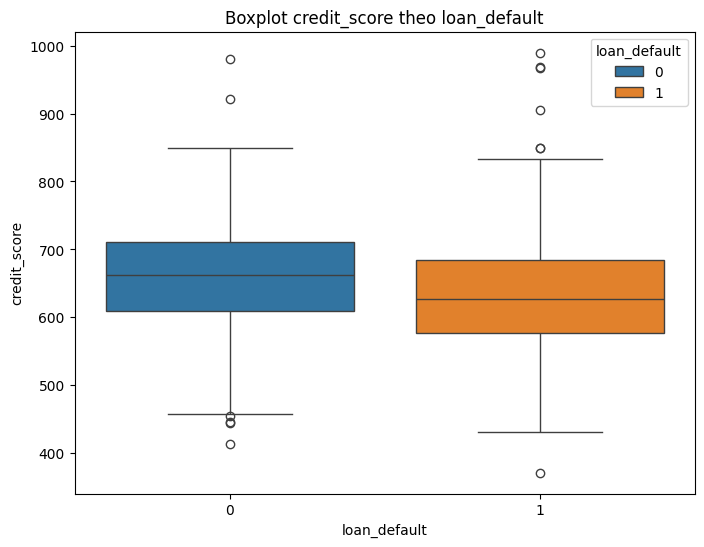

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x= 'loan_default', y = 'credit_score', hue = 'loan_default')
plt.title("Boxplot credit_score theo loan_default")
plt.show()

C:\Users\lequa\AppData\Local\Temp\ipykernel_2652\3207979648.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='loan_purpose', y='loan_default', palette='viridis')


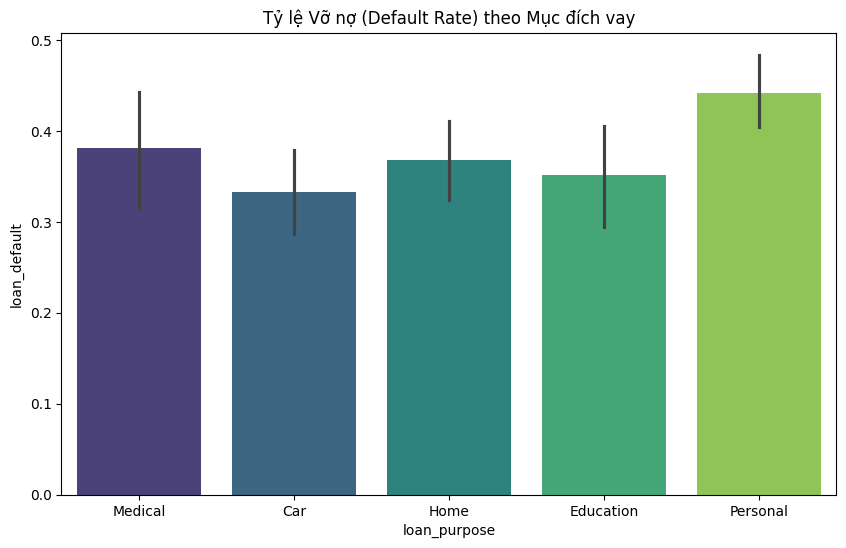

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(data=df, x='loan_purpose', y='loan_default', palette='viridis')

plt.title("Tỷ lệ Vỡ nợ (Default Rate) theo Mục đích vay")
plt.show()

In [7]:
before = len(df)

df = df[(df['age'].isna()) | (df['age'] < 100)]
df = df[(df['annual_income'].isna()) | (df['annual_income'] < 300000)]
df = df[(df['credit_score'].isna()) | (df['credit_score'] < 850)]
df = df.reset_index(drop=True)

print(f"Drop {before - len(df)} outliens rows → còn {len(df)} rows")

Drop 26 outliens rows → còn 1974 rows


In [8]:
df['annual_income'] =  df['annual_income'].fillna(
    df.groupby('education')['annual_income'].transform('median')
)
df['credit_score'] = df['credit_score'].fillna(
    df['credit_score'].median()
)
df['num_credit_cards'] = df['num_credit_cards'].fillna(
    df['num_credit_cards'].median()
)
df['months_employed'] = df['months_employed'].fillna(
    df['months_employed'].mode()[0]
)
print(f"Missing sau fill: {df.isnull().sum().sum()}") 

Missing sau fill: 0


In [9]:
df['dti_ratio'] = df['existing_debt'] / (df['annual_income'] + 1)

df['loan_to_income'] = df['loan_amount'] / (df['annual_income'] + 1)

df['monthly_payment'] = df['loan_amount'] / df['loan_term_months']

df['credit_util'] = df['existing_debt'] / (df['credit_score'] * 100 + 1)

In [10]:
encode_col = ['gender', 'education', 'marital_status', 'loan_purpose','property_ownership']
df_final = pd.get_dummies(df, columns=encode_col, drop_first=True, dtype= int)

print(f"Shape sau encoding: {df_final.shape}")
print(f"Null còn lại: {df_final.isnull().sum().sum()}")

Shape sau encoding: (1974, 27)
Null còn lại: 0


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, precision_recall_curve
)

X = df.drop(columns = ['loan_default'])
y = df['loan_default']

X_train, X_test, y_train, y_test = train_test_split(X, y , random_state= 42, stratify=y)



In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, encode_col)
])

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, roc_auc_score

pipelines = {
    'Logistic (no reg)': Pipeline([('pre', preprocessor), ('model', LogisticRegression(C=1e6, max_iter=1000))]),
    'Logistic L2 (Ridge)': Pipeline([('pre', preprocessor), ('model', LogisticRegression(C=0.1, max_iter=1000))]),
    'Logistic L1 (Lasso)': Pipeline([('pre', preprocessor), ('model', LogisticRegression(C=0.1, penalty='l1', solver='liblinear'))]),
    'Decision Tree':       Pipeline([('pre', preprocessor), ('model', DecisionTreeClassifier(max_depth=5, random_state=42))]),
    'Random Forest':       Pipeline([('pre', preprocessor), ('model', RandomForestClassifier(n_estimators=100, random_state=42))]),
}

results = []

for name, pipe in pipelines.items():
    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1',n_jobs=-1)
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=5 , scoring= 'roc_auc', n_jobs= -1)
    
    results.append({
        'Model': name,
        "F1_mean": cv_f1.mean(),
        "F1_std": cv_f1.std(),
        "AUC_mean": cv_auc.mean()
    })
    
print("=" * 70)
header = f"{'Model':<20} {'CV F1 (mean)':<15} {'CV F1 (std)':<15} {'CV AUC (mean)':<15}"
print(header)

for rows in results:
    print(f"{rows['Model']:<20} {rows['F1_mean']:<15f} {rows['F1_std']:<15f} {rows['AUC_mean']:<15f}")
print("=" * 70)



Model                CV F1 (mean)    CV F1 (std)     CV AUC (mean)  
Logistic (no reg)    0.493805        0.047082        0.698399       
Logistic L2 (Ridge)  0.476948        0.046805        0.701823       
Logistic L1 (Lasso)  0.472073        0.031970        0.704434       
Decision Tree        0.442003        0.064794        0.654925       
Random Forest        0.492186        0.040984        0.687611       


In [29]:
best_model_info = max(results, key = lambda x: x['F1_mean'])
best_model_name = best_model_info['Model']

print(f"Best Model được chọn: {best_model_name} (F1: {best_model_info['F1_mean']:.4f})")
best_pipe = pipelines[best_model_name]

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:,1]


metrics_results = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_prob)
}

for metric, value in metrics_results.items():
    print(f"{metric:<15}: {value:.4f}")
print(f"{'='*40}")

Best Model được chọn: Logistic (no reg) (F1: 0.4938)
Accuracy       : 0.6579
Precision      : 0.5664
Recall         : 0.4309
F1 Score       : 0.4894
AUC-ROC        : 0.7116


In [31]:
# 1. Lấy Pipeline Lasso
lasso_pipe = pipelines['Logistic L1 (Lasso)']

# 2. HUẤN LUYỆN (Quan trọng nhất - phải fit thì mới có coef_)
lasso_pipe.fit(X_train, y_train)

# 3. Truy cập vào model bên trong Pipeline
lasso_model = lasso_pipe.named_steps['model']

# 4. Bây giờ mới lấy được coef_
coefs = lasso_model.coef_[0]

# 5. Đếm số lượng feature bị loại (trọng số bằng 0)
n_zeros = (coefs == 0).sum()

print(f"Số lượng features bị Lasso loại bỏ (coef = 0): {n_zeros}")
lasso_model = pipelines['Logistic L1 (Lasso)'].named_steps['model']
# Lấy trọng số
coefs = lasso_model.coef_[0]
# Đếm số lượng bằng 0
n_zeros = (coefs == 0).sum()

print(f"Số lượng features bị Lasso loại bỏ (coef = 0): {n_zeros}")

Số lượng features bị Lasso loại bỏ (coef = 0): 11
Số lượng features bị Lasso loại bỏ (coef = 0): 11


C:\Users\lequa\AppData\Local\Temp\ipykernel_2652\2934473176.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_res, x='Model', y='F1_mean', palette='magma')


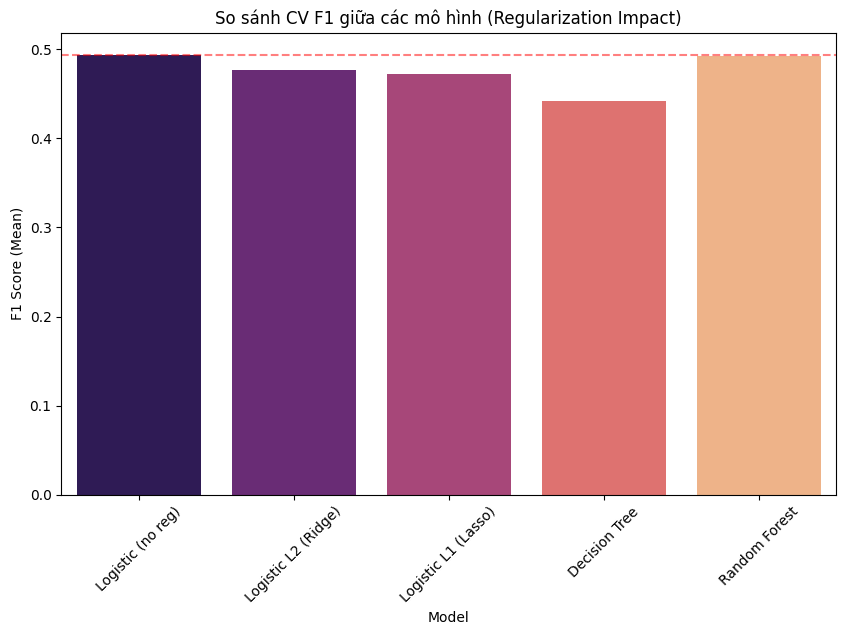

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_res = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_res, x='Model', y='F1_mean', palette='magma')

plt.axhline(df_res['F1_mean'].max(), color='red', linestyle='--', alpha=0.5)

plt.title('So sánh CV F1 giữa các mô hình (Regularization Impact)')
plt.ylabel('F1 Score (Mean)')
plt.xticks(rotation=45)
plt.show()